# a03 Example - AX

# Install External Libraries for Optimizer Implementation

In [ ]:
!python -m pip install ax-platform

# Imports

In [1]:
import pyscan as ps
import numpy as np
import matplotlib.pyplot as plt

from ax.api.client import Client
from ax.api.configs import RangeParameterConfig

## Setup devices

In [2]:
devices = ps.ItemAttribute()

devices.v1 = ps.TestVoltage() # Device 1
devices.v2 = ps.TestVoltage() # Device 2

## Define a measure function

In [3]:
def voltage_response(v1, v2):
    """
    Paraboloid function to optimize.
    """
    return (v1 - 4)**2 + (v2 - 6)**2

def get_voltage_data(expt):
    """
    Reads the voltage from v1 and v2. Also adds a calculated voltage response to optimize.
    """

    runinfo = expt.runinfo
    devices = expt.devices

    d = ps.ItemAttribute()

    d.v1_readout = devices.v1.voltage
    d.v2_readout = devices.v2.voltage

    d.vf = voltage_response(d.v1_readout, d.v2_readout)

    return d

# Define live plot

In [4]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, ax, cb0, cb1
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                cmap='viridis')
    ax.set_box_aspect(1)
    if cb0 is None and cb1 is None:
        cb0 = fig.colorbar(scatter, label="optimizer step")
        cb1 = fig.colorbar(pcm, label="voltage response")
    else:
        cb0.update_normal(scatter)
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

# Define runinfo

In [5]:
runinfo = ps.RunInfo()
runinfo.measure_function = get_voltage_data

# Implement `AbstractOptimizeScan` with `AXOptimizeScan`

In [6]:
class AXOptimizeScan(ps.AbstractOptimizeScan):
    """
    AX API
    """


    def __init__(self, initialization_dict, prop, optimizer_inputs, sample_function_output,
                 bounds_list,
                 dt=0., n_max=100,
                 extremum='min'):
        
        super().__init__(initialization_dict, prop, optimizer_inputs, sample_function_output,
                         dt=dt, n_max=n_max)

        self.last_optim_idx = n_max - 2 # stop optimizing on second-to-last index so that last index is best discovered value   
        self.set_final_opt = False
        self.proposed_trial_index = None
    
        parameters = [
            RangeParameterConfig(name=self.opt_in[i], parameter_type="float", bounds=bounds_list[i])
            for i in range(len(self.opt_in))
        ]
        self.client = Client()
        self.client.configure_experiment(parameters=parameters)
        match extremum:
            case 'max':
                self.objective = f"{self.sample_f_out}"
            case 'min':
                self.objective = f"-{self.sample_f_out}"
            case _:
                raise ValueError('Extremum must be max or min')
        self.client.configure_optimization(objective=self.objective)


    def step_optimizer(self, index, experiment):

        if self.set_final_opt:
            best_parameters, prediction, index, name = self.client.get_best_parameterization()
            f_in_next = [
                    best_parameters[measurement]
                    for measurement in self.opt_in
                ]
            return f_in_next
        
        else:

            if index == 1: # load initial point into AX measurement history
                parameters = {
                    measurement: experiment.__dict__[measurement][0]
                    for measurement in self.opt_in
                }
                prev_trial_index = self.client.attach_trial(parameters=parameters)
            else: # load last proposed trial results into AX measurement history
                f_out = experiment.__dict__[self.sample_f_out][index - 1]
                raw_data = {self.sample_f_out: f_out}
                prev_trial_index = self.proposed_trial_index
                self.client.complete_trial(trial_index=prev_trial_index, raw_data=raw_data)

            trials = self.client.get_next_trials(max_trials=1) # only 1 trial
            for trial_index, parameters in trials.items(): # only 1 item
                f_in_next = [
                    parameters[measurement]
                    for measurement in self.opt_in
                ]
                self.proposed_trial_index = trial_index
            
            self.set_final_opt = not (index < self.last_optim_idx)

            return f_in_next


# Instantiate OptimizeScan

In [ ]:
runinfo.scan0 = AXOptimizeScan({'v1': 2., 'v2': 1.}, 'voltage', ('v1_readout', 'v2_readout'), 'vf',
                               ((0., 10.), (0., 10.)),
                               dt=1., n_max=20)

# Run Experiments

In [ ]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

[INFO 12-01 11:54:54] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(node_name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(node_name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[INFO 12-01 11:54:54] ax.api.client: Generated new trial 1 with parameters {'v1_readout': 5.0, 'v2_readout': 5.0} using GenerationNode CenterOfSearchSpace.
[INFO 12-01 11:54:55] ax.api.client: Trial 1 marked COMPLETED.
[INFO 12-01 11:54:55] ax.api.client: Generated new trial 2 with parameters {'v1_readout': 8.88149, 'v2_readout': 9.491385} using GenerationNode Sobol.
[INFO 12-01 11:54:57] ax.api.client: Trial 2 marked COMPLETED.
[INFO 12-01 11:54:57] ax.api.client: 

Stopping Experiment


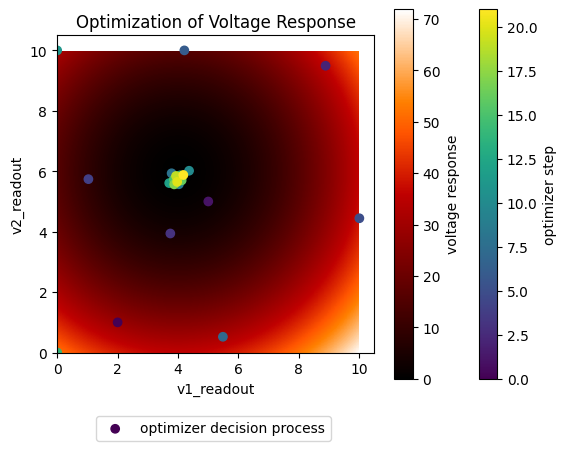

In [9]:
fig, ax = plt.subplots()
cb0 = cb1 = None
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [ ]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x19e83e8ede0>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x19ef2fe36b0>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 53148)>,
 'iteration': array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 'v1_readout': array([2.        , 5.        , 5.49913108, 0.27699487, 3.57853674,
        6.75734388, 3.77336065, 2.00633243, 4.12689318, 9.38688277]),
 'v2_readout': array([1.        , 5.        , 8.58836412, 3.12584348, 5.1486249 ,
        5.91472135, 6.25771992, 8.78139449, 5.82276979, 0.        ]),
 'vf': array([2.90000000e+01, 2.00000000e+00, 8.94702285e+00, 2.21215429e+01,
        9.02470840e-01, 7.61021772e+00, 1.17784953e-01, 1.17108657e+01,
        4.75124282e-02, 6.50185060e+01])}

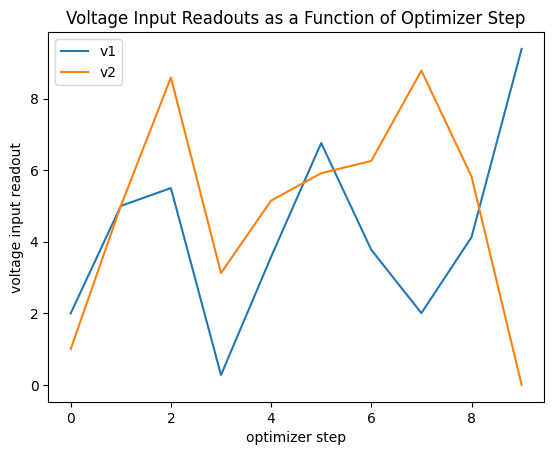

In [ ]:
plt.plot(list(zip(expt.v1_readout, expt.v2_readout)))
plt.legend(['v1', 'v2'])
plt.xlabel("optimizer step")
plt.ylabel("voltage input readout")
plt.title("Voltage Input Readouts as a Function of Optimizer Step");

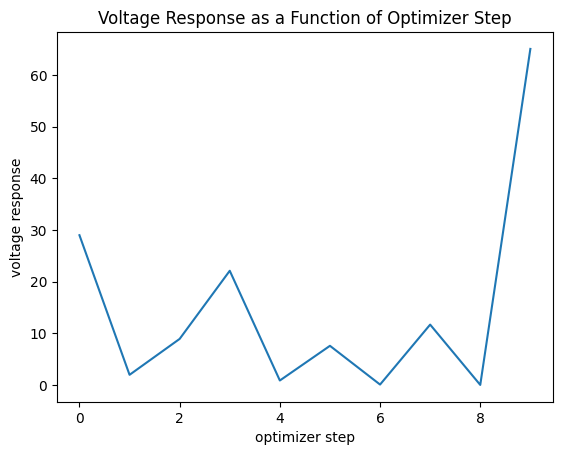

In [ ]:
plt.plot(expt.vf)
plt.xlabel("optimizer step")
plt.ylabel("voltage response")
plt.title("Voltage Response as a Function of Optimizer Step");

In [ ]:
def plot_optim_pcm():
    fig, ax = plt.subplots()
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                         cmap='viridis')
    ax.set_box_aspect(1)
    fig.colorbar(scatter, label="optimizer step")
    fig.colorbar(pcm, label="voltage response")
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

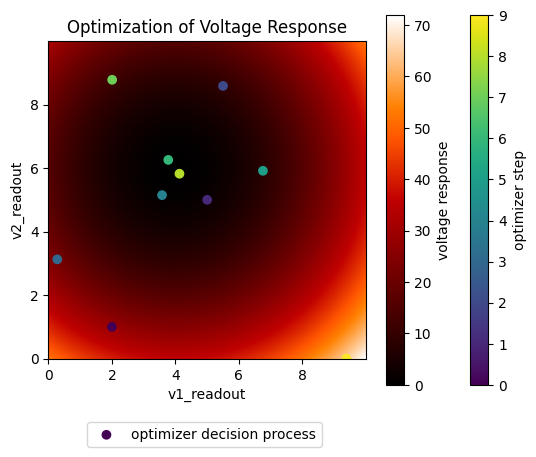

In [ ]:
plot_optim_pcm()

In [ ]:
def plot_optim_3d(elevation, azimuth):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    ax.plot_surface(x, y, z, color='C1', alpha=.5)
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, expt.vf, c=range(len(expt.v1_readout)))
    ax.view_init(elev=elevation, azim=azimuth)
    fig.colorbar(scatter, label="optimizer step", pad=.1)
    ax.legend(["voltage response function", "optimizer decision process",], loc='lower left', bbox_to_anchor=(.2, -.2))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_zlabel("voltage response")
    ax.set_title("Optimization of Voltage Response")

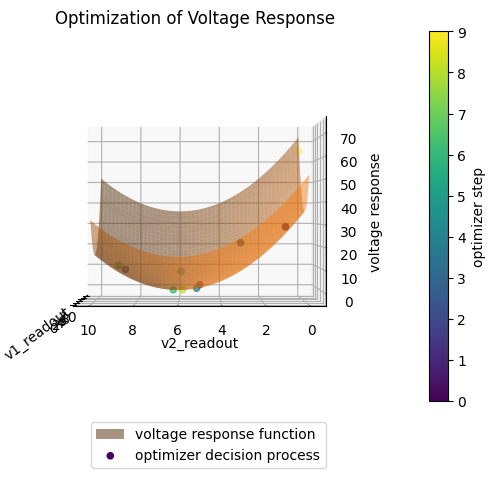

In [ ]:
plot_optim_3d(0, 180)

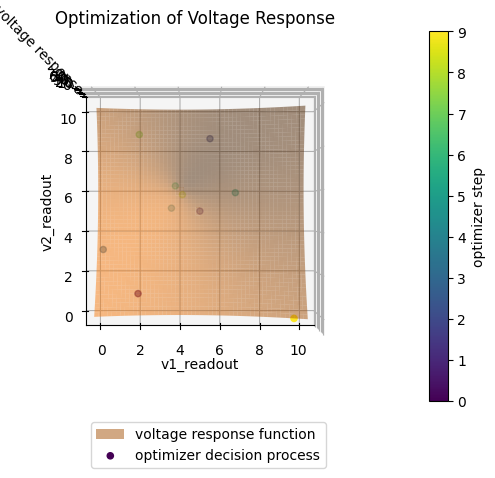

In [ ]:
plot_optim_3d(90, 270)

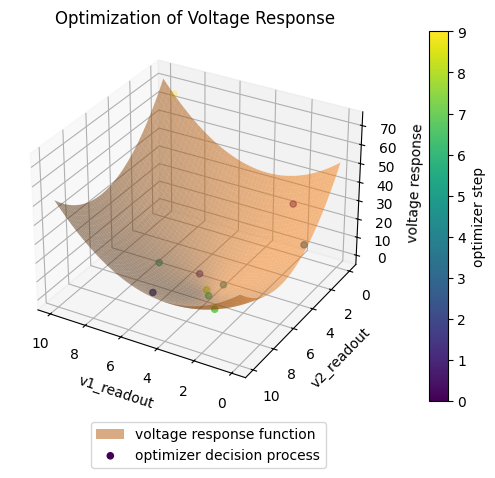

In [ ]:
plot_optim_3d(30, 120)